In [1]:
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from scipy import stats # библиотека для расчетов
from sklearn.metrics import matthews_corrcoef
import category_encoders as ce

In [2]:
wine_data = pd.read_csv('data/wine_cleared.csv', index_col=0)

In [3]:
wine_data.head()

,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,35.363389,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.000000,Douro,unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",unknown,87,14.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.000000,Michigan,Lake Michigan Shore,Alexander Peartree,unknown,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [4]:
wine_data['points'].min()

80

In [5]:
wine_data['price'].min()

4.0

In [6]:
round(statistics.mean(wine_data['price']), 2)

35.36

In [7]:
wine_data['price'].mean()

35.36338912999136

In [8]:
round(statistics.median(wine_data['price']), 2)

28.0

In [9]:
n = len(wine_data['price']) // 2 - 1
sort_data = wine_data['price'].sort_values(ignore_index=True)

if len(sort_data) % 2 == 0:
    median_price = round(sort_data[n], 2)
else:
    median_price = round((sort_data[n] + sort_data[n + 1]) / 2, 2)

In [10]:
round(statistics.mode(wine_data['price']), 2)

35.36

In [11]:
values = wine_data['price'].unique()
counter_prices = dict()

for item in values:
    counter_prices[item] = list(wine_data['price']).count(item)
    
max_value = max(counter_prices.values())

for item in counter_prices.keys():
    if counter_prices[item] == max_value:
        mode_price = item

In [12]:
wine_data.corr()

,points,price
points,1.000000,0.402137
price,0.402137,1.000000


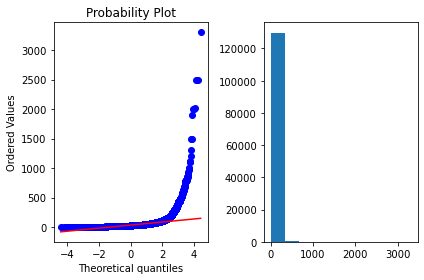

In [13]:
plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(wine_data['price'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(wine_data['price']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

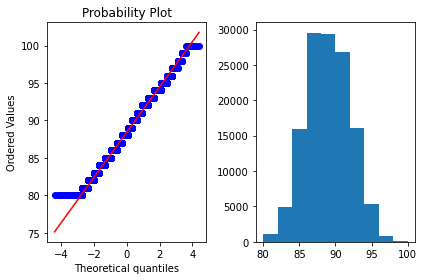

In [14]:
plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(wine_data['points'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(wine_data['points']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

In [15]:
round(wine_data.corr(method='spearman'), 2)

,points,price
points,1.00,0.58
price,0.58,1.00


In [16]:
round(wine_data.corr(method='kendall'), 2)

,points,price
points,1.00,0.43
price,0.43,1.00


In [17]:
x = [+1, -1, +1, +1] # список значений признака х
y = [+1, +1, +1, -1] # список значений признака y

matthews_corrcoef(x, y) # рассчитаем коэффициент корреляции Мэтьюса

-0.3333333333333333